In [1]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 6})
import sys
sys.path.append('..')
import cmcrameri
import torch

import warnings
warnings.filterwarnings("ignore")

from omegaconf import OmegaConf

from solo.data.classification_dataloader import prepare_data
from solo.methods import METHODS
from scripts.utils.get_images_and_feats import get_images_and_feats

In [2]:
# set up plot dir
plot_dir = Path("plots/cifar/")
plot_dir.mkdir(parents=True, exist_ok=True)

In [3]:

dataset = "cifar10"
val_data_path = "../datasets/cifar10/val"
train_data_path = "../datasets/"
data_format = "image_folder"
batch_size = 256
num_workers = 4

# prepare data
train_loader, val_loader = prepare_data(
    dataset,
    train_data_path=train_data_path,
    val_data_path=val_data_path,
    data_format=data_format,
    batch_size=batch_size,
    num_workers=num_workers,
    auto_augment=False,
)

In [4]:
def load_model(model_name, run_name):
    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    names = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))
    for n in names:
        run = folder_name + n
        args_file = os.path.join(run, "args.json")
        args = json.load(open(args_file, "r"))
        if args["name"] == run_name:
            pretrained_checkpoint_dir = run
            name = n
    cfg = OmegaConf.create(args)

    # build paths
    ckpt_dir = Path(pretrained_checkpoint_dir)
    args_path = ckpt_dir / "args.json"
    ckpt_path = [ckpt_dir / ckpt for ckpt in os.listdir(ckpt_dir) if ckpt.endswith(".ckpt")][0]

    # load arguments
    with open(args_path) as f:
        method_args = json.load(f)
    cfg = OmegaConf.create(method_args)

    # build the model
    model = (
        METHODS[method_args["method"]]
        .load_from_checkpoint(ckpt_path, strict=False, cfg=cfg)
    )

    # move model to the gpu
    device = "cuda:0"
    model = model.to(device)

    # get images and features
    data, labels, z = get_images_and_feats(device, model, val_loader)
    # clip data for imshow
    # data = np.clip(data, 0, 1)

    return data, labels, z, model, name

In [ ]:
model_name = "gaussprob"
run_name = "gaussprob_cifar10_dual_sample"
data, labels, z_gauss_dual_sample, model_gauss_dual_sample, name_gauss_dual_sample = load_model(model_name, run_name)
run_name = "gaussprob_cifar10_single_sample"
_, _, z_gauss_single_sample, model_gauss_single_sample, name_gauss_single_sample = load_model(model_name, run_name)
run_name = "gaussprob_cifar10_dual_knn"
_, _, z_gauss_dual_knn, model_gauss_dual_knn, name_gauss_dual_knn = load_model(model_name, run_name)
run_name = "gaussprob_cifar10_single_knn"
_, _, z_gauss_single_knn, model_gauss_single_knn, name_gauss_single_knn = load_model(model_name, run_name)
model_name = "vicreg2" 
run_name = "vicreg2_cifar10_lower_entropy"
_, _, z_gauss_dual_logdet, model_gauss_dual_logdet, name_gauss_dual_logdet = load_model(model_name, run_name)
model_name = "vicreg"
run_name = "vicreg-cifar10"
_, _, z_gauss_single_logdet, model_gauss_single_logdet, name_gauss_single_logdet = load_model(model_name, run_name)
model_name = "sphereprob"
run_name = "sphereprob_cifar10_dual_sample"
_, _, z_sphere_dual_sample, model_sphere_dual_sample, name_sphere_dual_sample = load_model(model_name, run_name)
run_name = "sphereprob_cifar10_single_sample"
_, _, z_sphere_single_sample, model_sphere_single_sample, name_sphere_single_sample = load_model(model_name, run_name)
run_name = "sphereprob_cifar10_dual_knn"
_, _, z_sphere_dual_knn, model_sphere_dual_knn, name_sphere_dual_knn = load_model(model_name, run_name)
run_name = "sphereprob_cifar10_single_knn"
_, _, z_sphere_single_knn, model_sphere_single_knn, name_sphere_single_knn = load_model(model_name, run_name)
run_name = "sphereprob_cifar10_dual_gauss"
_, _, z_sphere_dual_gauss, model_sphere_dual_gauss, name_sphere_dual_gauss = load_model(model_name, run_name)
run_name = "sphereprob_cifar10_single_gauss"
_, _, z_sphere_single_gauss, model_sphere_single_gauss, name_sphere_single_gauss = load_model(model_name, run_name)

model_dict = {
    r"Plane Contr.": (z_gauss_dual_sample, model_gauss_dual_sample),
    r"Plane Contr. + MI": (z_gauss_single_sample, model_gauss_single_sample),
    r"Plane kNN": (z_gauss_dual_knn, model_gauss_dual_knn),
    r"Plane kNN + MI": (z_gauss_single_knn, model_gauss_single_knn),
    r"Plane LogDet": (z_gauss_dual_logdet, model_gauss_dual_logdet),
    r"Plane LogDet + MI": (z_gauss_single_logdet, model_gauss_single_logdet),
    r"Sphere Contr.": (z_sphere_dual_sample, model_sphere_dual_sample),
    r"Sphere Contr. + MI": (z_sphere_single_sample, model_sphere_single_sample),
    r"Sphere kNN": (z_sphere_dual_knn, model_sphere_dual_knn),
    r"Sphere kNN + MI": (z_sphere_single_knn, model_sphere_single_knn),
    r"Sphere LogDet": (z_sphere_dual_gauss, model_sphere_dual_gauss),
    r"Sphere LogDet + MI": (z_sphere_single_gauss, model_sphere_single_gauss),
}

In [ ]:
# plot log distance distribution between encodings
z = z_gauss_dual_sample
distances = torch.cdist(torch.tensor(z), torch.tensor(z)).numpy().flatten()
plt.figure(figsize=(3,2))
plt.hist(np.log10(distances + 1e-10), bins=100, density=True, color='blue', alpha=0.7)
plt.xlabel('Log10 Distance')
plt.ylabel('Density')
plt.title('Log10 Distance Distribution (Gauss Dual Sample)')
plt.tight_layout()
plt.savefig(plot_dir / "cifar10_log_distance_gauss_dual_sample.png", dpi=300)
plt.close()



In [ ]:
print(data.shape)
print(labels.shape)
print(z_gauss_dual_sample.shape)
print(z_sphere_dual_sample.shape)

(10000, 3, 32, 32)
(10000,)
(10000, 2048)
(10000, 256)


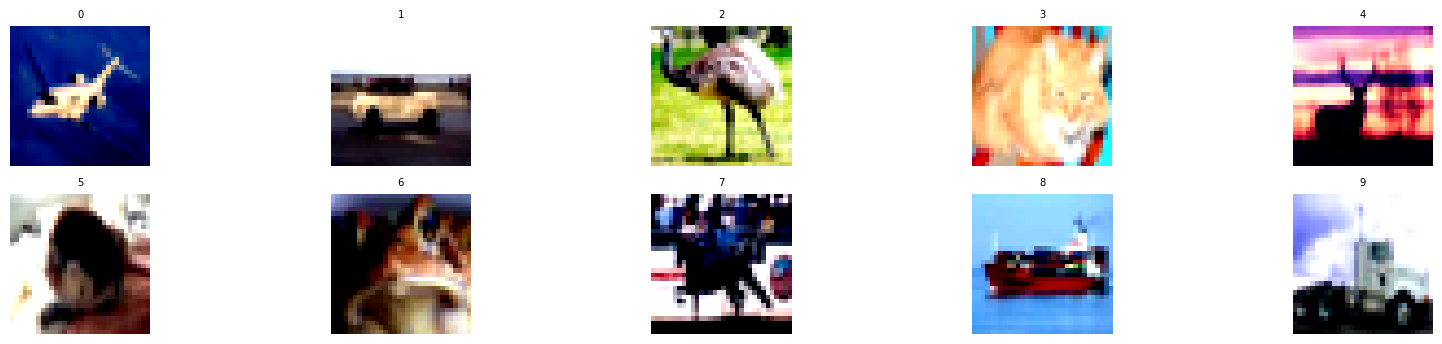

In [ ]:
# plot some images and labels
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    j = 200
    while labels[j] != i:
        j += 1
    ax = plt.subplot(2, n//2, i+1)
    plt.imshow((data[j].transpose(1,2,0) * 0.5 + 0.5).clip(0,1))
    plt.title(f"{labels[j]}")
    plt.axis("off")
plt.show()

In [ ]:
eigenvalue_dict = {}
for name, (z, model) in model_dict.items():
    print(f"Computing eigenvalues for {name}...")
    cov = np.cov(z, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov)
    eigenvalues = np.sort(eigenvalues)[::-1]
    eigenvalue_dict[name] = eigenvalues


Computing eigenvalues for Plane Contr....
Computing eigenvalues for Plane Contr. + MI...
Computing eigenvalues for Plane kNN...
Computing eigenvalues for Plane kNN + MI...
Computing eigenvalues for Plane LogDet...
Computing eigenvalues for Plane LogDet + MI...
Computing eigenvalues for Sphere Contr....
Computing eigenvalues for Sphere Contr. + MI...
Computing eigenvalues for Sphere kNN...
Computing eigenvalues for Sphere kNN + MI...
Computing eigenvalues for Sphere LogDet...
Computing eigenvalues for Sphere LogDet + MI...


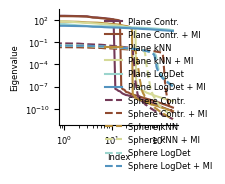

In [ ]:
cmap = cmcrameri.cm.romaO
plot_dict = {
    r"Plane Contr.": {"color": cmap(0.0), "linestyle": "-"},
    r"Plane Contr. + MI": {"color": cmap(0.15), "linestyle": "-"},
    r"Plane kNN": {"color": cmap(0.3), "linestyle": "-"},
    r"Plane kNN + MI": {"color": cmap(0.45), "linestyle": "-"},
    r"Plane LogDet": {"color": cmap(0.6), "linestyle": "-"},
    r"Plane LogDet + MI": {"color": cmap(0.75), "linestyle": "-"},
    r"Sphere Contr.": {"color": cmap(0.0), "linestyle": "--"},
    r"Sphere Contr. + MI": {"color": cmap(0.15), "linestyle": "--"},
    r"Sphere kNN": {"color": cmap(0.3), "linestyle": "--"},
    r"Sphere kNN + MI": {"color": cmap(0.45), "linestyle": "--"},
    r"Sphere LogDet": {"color": cmap(0.6), "linestyle": "--"},
    r"Sphere LogDet + MI": {"color": cmap(0.75), "linestyle": "--"},
}

plt.figure(figsize=(2.5,1.7))

for name, eigenvalues in eigenvalue_dict.items():
    plt_params = plot_dict[name]
    # eigenspectrum of covariance matrix
    plt.plot(eigenvalues[:200], label=name, color=plt_params["color"], linestyle=plt_params["linestyle"])

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1.35, 1), frameon=False)
plt.tight_layout()
plt.savefig(plot_dir / "spectrum.pdf")

In [ ]:
from sklearn.manifold import TSNE
tsne_dict = {}

tsne = TSNE(n_components=2, perplexity=30, max_iter=3000, random_state=42)
n = 1000

for name, (z, model) in model_dict.items():
    print(f"Computing t-SNE for {name}...")
    z_subset = z[:n]
    z_tsne = tsne.fit_transform(z_subset)
    tsne_dict[name] = (z_tsne, model)

Computing t-SNE for Plane Contr....
Computing t-SNE for Plane Contr. + MI...
Computing t-SNE for Plane kNN...
Computing t-SNE for Plane kNN + MI...
Computing t-SNE for Plane LogDet...
Computing t-SNE for Plane LogDet + MI...
Computing t-SNE for Sphere Contr....
Computing t-SNE for Sphere Contr. + MI...
Computing t-SNE for Sphere kNN...
Computing t-SNE for Sphere kNN + MI...
Computing t-SNE for Sphere LogDet...
Computing t-SNE for Sphere LogDet + MI...


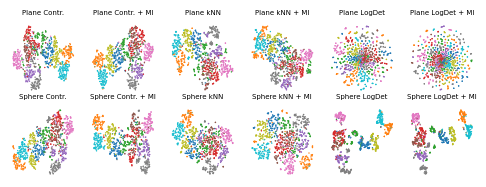

In [ ]:
# t-sne visualization
from math import ceil
fig, ax = plt.subplots(2, ceil(len(model_dict)/2), figsize=(len(model_dict)*0.5, 2.0))
ax = ax.flatten()
i = 0
for name, (z_tsne, model) in tsne_dict.items():
    ax[i].scatter(z_tsne[:,0], z_tsne[:,1], c=labels[:n], cmap='tab10', s=1.0, linewidths=0)
    ax[i].axis('off')
    ax[i].set_title(name, fontsize=5)
    i += 1

# plt.colorbar(ax=ax, mappable=ax[0].collections[0], orientation='horizontal', fraction=0.03, pad=0.1, ticks=range(10))
plt.savefig(plot_dir / "tsne.pdf")

In [ ]:
dataset = "cifar100"
val_data_path = "../datasets/"
train_data_path = "../datasets/"
data_format = "image_folder"
batch_size = 256
num_workers = 4

# prepare data
train_loader, val_loader = prepare_data(
    dataset,
    train_data_path=train_data_path,
    val_data_path=val_data_path,
    data_format=data_format,
    batch_size=batch_size,
    num_workers=num_workers,
    auto_augment=False,
)

In [ ]:
model_name = "gaussprob"
run_name = "gaussprob_cifar100_dual_sample"
data, labels, z_gauss_dual_sample, model_gauss_dual_sample, name_gauss_dual_sample = load_model(model_name, run_name)
run_name = "gaussprob_cifar100_single_sample"
_, _, z_gauss_single_sample, model_gauss_single_sample, name_gauss_single_sample = load_model(model_name, run_name)
run_name = "gaussprob_cifar100_dual_knn"
_, _, z_gauss_dual_knn, model_gauss_dual_knn, name_gauss_dual_knn = load_model(model_name, run_name)
run_name = "gaussprob_cifar100_single_knn"
_, _, z_gauss_single_knn, model_gauss_single_knn, name_gauss_single_knn = load_model(model_name, run_name)
model_name = "vicreg2" 
run_name = "vicreg2_cifar100_lower_entropy"
_, _, z_gauss_dual_logdet, model_gauss_dual_logdet, name_gauss_dual_logdet = load_model(model_name, run_name)
model_name = "vicreg"
run_name = "vicreg-cifar100"
_, _, z_gauss_single_logdet, model_gauss_single_logdet, name_gauss_single_logdet = load_model(model_name, run_name)
model_name = "sphereprob"
run_name = "sphereprob_cifar100_dual_sample"
_, _, z_sphere_dual_sample, model_sphere_dual_sample, name_sphere_dual_sample = load_model(model_name, run_name)
run_name = "sphereprob_cifar100_single_sample"
_, _, z_sphere_single_sample, model_sphere_single_sample, name_sphere_single_sample = load_model(model_name, run_name)
run_name = "sphereprob_cifar100_dual_knn"
_, _, z_sphere_dual_knn, model_sphere_dual_knn, name_sphere_dual_knn = load_model(model_name, run_name)
run_name = "sphereprob_cifar100_single_knn"
_, _, z_sphere_single_knn, model_sphere_single_knn, name_sphere_single_knn = load_model(model_name, run_name)
run_name = "sphereprob_cifar100_dual_gauss"
_, _, z_sphere_dual_gauss, model_sphere_dual_gauss, name_sphere_dual_gauss = load_model(model_name, run_name)
run_name = "sphereprob_cifar100_single_gauss"
_, _, z_sphere_single_gauss, model_sphere_single_gauss, name_sphere_single_gauss = load_model(model_name, run_name)

name_dict = {
    r"Plane Contr.": name_gauss_dual_sample,
    r"Plane Contr. + MI": name_gauss_single_sample,
    r"Plane kNN": name_gauss_dual_knn,
    r"Plane kNN + MI": name_gauss_single_knn,
    r"Plane LogDet": name_gauss_dual_logdet,
    r"Plane LogDet + MI": name_gauss_single_logdet,
    r"Sphere Contr.": name_sphere_dual_sample,
    r"Sphere Contr. + MI": name_sphere_single_sample,
    r"Sphere kNN": name_sphere_dual_knn,
    r"Sphere kNN + MI": name_sphere_single_knn,
    r"Sphere LogDet": name_sphere_dual_gauss,
    r"Sphere LogDet + MI": name_sphere_single_gauss,
}

model_dict = {
    r"Plane Contr.": (z_gauss_dual_sample, model_gauss_dual_sample),
    r"Plane Contr. + MI": (z_gauss_single_sample, model_gauss_single_sample),
    r"Plane kNN": (z_gauss_dual_knn, model_gauss_dual_knn),
    r"Plane kNN + MI": (z_gauss_single_knn, model_gauss_single_knn),
    r"Plane LogDet": (z_gauss_dual_logdet, model_gauss_dual_logdet),
    r"Plane LogDet + MI": (z_gauss_single_logdet, model_gauss_single_logdet),
    r"Sphere Contr.": (z_sphere_dual_sample, model_sphere_dual_sample),
    r"Sphere Contr. + MI": (z_sphere_single_sample, model_sphere_single_sample),
    r"Sphere kNN": (z_sphere_dual_knn, model_sphere_dual_knn),
    r"Sphere kNN + MI": (z_sphere_single_knn, model_sphere_single_knn),
    r"Sphere LogDet": (z_sphere_dual_gauss, model_sphere_dual_gauss),
    r"Sphere LogDet + MI": (z_sphere_single_gauss, model_sphere_single_gauss),
}

cmap = cmcrameri.cm.romaO
plot_dict = {
    r"Plane Contr.": {"color": cmap(0.0), "linestyle": "-"},
    r"Plane Contr. + MI": {"color": cmap(0.15), "linestyle": "-"},
    r"Plane kNN": {"color": cmap(0.3), "linestyle": "-"},
    r"Plane kNN + MI": {"color": cmap(0.45), "linestyle": "-"},
    r"Plane LogDet": {"color": cmap(0.6), "linestyle": "-"},
    r"Plane LogDet + MI": {"color": cmap(0.75), "linestyle": "-"},
    r"Sphere Contr.": {"color": cmap(0.0), "linestyle": "--"},
    r"Sphere Contr. + MI": {"color": cmap(0.15), "linestyle": "--"},
    r"Sphere kNN": {"color": cmap(0.3), "linestyle": "--"},
    r"Sphere kNN + MI": {"color": cmap(0.45), "linestyle": "--"},
    r"Sphere LogDet": {"color": cmap(0.6), "linestyle": "--"},
    r"Sphere LogDet + MI": {"color": cmap(0.75), "linestyle": "--"},
}

In [ ]:
cmap = cmcrameri.cm.romaO
plot_dict = {
    r"Plane Contr.": {"color": cmap(0.0), "linestyle": "-"},
    r"Plane Contr. + MI": {"color": cmap(0.15), "linestyle": "-"},
    r"Plane kNN": {"color": cmap(0.3), "linestyle": "-"},
    r"Plane kNN + MI": {"color": cmap(0.45), "linestyle": "-"},
    r"Plane LogDet": {"color": cmap(0.6), "linestyle": "-"},
    r"Plane LogDet + MI": {"color": cmap(0.75), "linestyle": "-"},
    r"Sphere Contr.": {"color": cmap(0.0), "linestyle": "--"},
    r"Sphere Contr. + MI": {"color": cmap(0.15), "linestyle": "--"},
    r"Sphere kNN": {"color": cmap(0.3), "linestyle": "--"},
    r"Sphere kNN + MI": {"color": cmap(0.45), "linestyle": "--"},
    r"Sphere LogDet": {"color": cmap(0.6), "linestyle": "--"},
    r"Sphere LogDet + MI": {"color": cmap(0.75), "linestyle": "--"},
}

In [ ]:
eigenvalue_dict = {}
for name, (z, model) in model_dict.items():
    print(f"Computing eigenvalues for {name}...")
    cov = np.cov(z, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov)
    eigenvalues = np.sort(eigenvalues)[::-1]
    eigenvalue_dict[name] = eigenvalues


Computing eigenvalues for Plane Contr....
Computing eigenvalues for Plane Contr. + MI...
Computing eigenvalues for Plane kNN...


Computing eigenvalues for Plane kNN + MI...
Computing eigenvalues for Plane LogDet...
Computing eigenvalues for Plane LogDet + MI...
Computing eigenvalues for Sphere Contr....
Computing eigenvalues for Sphere Contr. + MI...
Computing eigenvalues for Sphere kNN...
Computing eigenvalues for Sphere kNN + MI...
Computing eigenvalues for Sphere LogDet...
Computing eigenvalues for Sphere LogDet + MI...


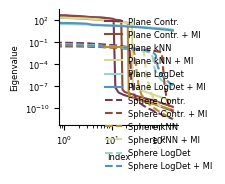

In [ ]:
cmap = cmcrameri.cm.romaO
plot_dict = {
    r"Plane Contr.": {"color": cmap(0.0), "linestyle": "-"},
    r"Plane Contr. + MI": {"color": cmap(0.15), "linestyle": "-"},
    r"Plane kNN": {"color": cmap(0.3), "linestyle": "-"},
    r"Plane kNN + MI": {"color": cmap(0.45), "linestyle": "-"},
    r"Plane LogDet": {"color": cmap(0.6), "linestyle": "-"},
    r"Plane LogDet + MI": {"color": cmap(0.75), "linestyle": "-"},
    r"Sphere Contr.": {"color": cmap(0.0), "linestyle": "--"},
    r"Sphere Contr. + MI": {"color": cmap(0.15), "linestyle": "--"},
    r"Sphere kNN": {"color": cmap(0.3), "linestyle": "--"},
    r"Sphere kNN + MI": {"color": cmap(0.45), "linestyle": "--"},
    r"Sphere LogDet": {"color": cmap(0.6), "linestyle": "--"},
    r"Sphere LogDet + MI": {"color": cmap(0.75), "linestyle": "--"},
}

plt.figure(figsize=(2.5,1.7))

for name, eigenvalues in eigenvalue_dict.items():
    plt_params = plot_dict[name]
    # eigenspectrum of covariance matrix
    plt.plot(eigenvalues[:200], label=name, color=plt_params["color"], linestyle=plt_params["linestyle"])

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=6, loc='upper right', bbox_to_anchor=(1.35, 1), frameon=False)
plt.tight_layout()
plt.savefig(plot_dir / "spectrum_cifar100.pdf")

In [ ]:
import wandb
import pandas as pd

# get wandb api key
wandb.login()
api = wandb.Api()


def get_cos_sim(model_name):
    # get the project name
    project_name = "<yourname>/solo-learn"
    run = api.run(f"{project_name}/{model_name}")
    metrics = run.history(keys=["train_entropy_cos_sim_epoch"])
    cos_sim = metrics["train_entropy_cos_sim_epoch"]
    # remove nan values
    # cos_sim = [x for x in cos_sim if not pd.isna(x)]
    return cos_sim

cos_sim_dict = {}
for name, settings in plot_dict.items():
    print(f"Getting cosine similarity for {name} at {name_dict[name]}...")
    try:
        cos_sim = get_cos_sim(name_dict[name])
        cos_sim_dict[name] = cos_sim
    except Exception as e:
        print(f"Could not get cosine similarity for {name}: {e}")
        cos_sim_dict[name] = []

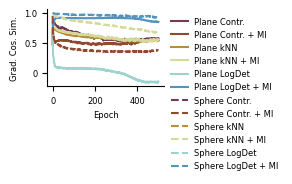

In [ ]:

plt.figure(figsize=(1.5,1.0))
for name, settings in plot_dict.items():
    cos_sim = cos_sim_dict[name]
    plt.plot(cos_sim, label=name, color=settings["color"], linestyle=settings["linestyle"])

# remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Epoch")
plt.ylabel("Grad. Cos. Sim.")
plt.yticks(ticks=[0, 0.5, 1.0], labels=[0, 0.5, 1.0])
# legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.savefig(plot_dir / "grad_cos_sim_cifar.pdf", bbox_inches='tight')

In [ ]:

def compute_jacobian(model, data):
    model.eval()
    device = next(model.parameters()).device
    data = torch.tensor(data).to(device)
    data.requires_grad_(True)
    with torch.enable_grad():
        outputs = model.backbone(data)
        outputs = model.projector(outputs)
    jacobians = []
    for i in range(outputs.shape[1]):
        grad_outputs = torch.zeros_like(outputs)
        grad_outputs[:, i] = 1
        grads = torch.autograd.grad(
            outputs,
            data,
            grad_outputs=grad_outputs,
            retain_graph=True,
            create_graph=False,
            only_inputs=True,
        )[0]
        jacobians.append(grads.cpu().numpy())
    jacobian = np.stack(jacobians, axis=1)  # shape: (batch_size, output_dim, input_dim)
    return jacobian.reshape((data.shape[0], -1, data.shape[1] * data.shape[2] * data.shape[3]))

In [ ]:
from math import ceil

# compute the jacobian of the encoder network for all models
log_det_dict = {}

for name, (z, model) in model_dict.items():
    print(f"Computing Jacobian for {name}...")
    J = compute_jacobian(model, data[:10])
    print(f"  Jacobian shape: {J.shape}")
    
    # compute log det of the jacobian's gram matrix
    log_dets = []
    for i in range(J.shape[0]):
        J_i = J[i]  # shape: (output_dim, input_dim)
        gram_matrix = J_i @ J_i.T  # shape: (output_dim, output_dim)
        # add a small value to the diagonal for numerical stability
        gram_matrix += 1e-6 * np.eye(gram_matrix.shape[0])
        logdet = np.linalg.matrix_rank(gram_matrix, hermitian=True)
        print(logdet)
        log_dets.append(logdet)
    log_det_dict[name] = log_dets

# plot histograms of log dets for all models
fig, ax = plt.subplots(2, ceil(len(model_dict)/2), figsize=(len(model_dict)*0.5, 2.0))
ax = ax.flatten()

for i, (name, log_dets) in enumerate(log_det_dict.items()):
    ax[i].hist(log_dets, bins=20, color='blue', alpha=0.7)
    ax[i].set_xlabel('Log Det', fontsize=5)
    ax[i].set_ylabel('Freq', fontsize=5)
    ax[i].set_title(name, fontsize=5)
    ax[i].tick_params(labelsize=4)

plt.tight_layout()
plt.savefig(plot_dir / "jacobian_log_det_histograms.pdf")
plt.show()

# cifar10 acc.

In [16]:


def get_run_names(model_name, run_name):
    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    names = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))
    res = []
    for n in names:
        run = folder_name + n
        args_file = os.path.join(run, "args.json")
        args = json.load(open(args_file, "r"))
        if args["name"] == run_name:
            res.append(n)
    return res

model_name = "gaussprob"
run_name = "gaussprob_cifar10_dual_sample"
names_gauss_dual_sample = get_run_names(model_name, run_name)
run_name = "gaussprob_cifar10_single_sample"
names_gauss_single_sample = get_run_names(model_name, run_name)
run_name = "gaussprob_cifar10_dual_knn"
names_gauss_dual_knn = get_run_names(model_name, run_name)
run_name = "gaussprob_cifar10_single_knn"
names_gauss_single_knn = get_run_names(model_name, run_name)
model_name = "vicreg2" 
run_name = "vicreg2_cifar10_lower_entropy"
names_gauss_dual_logdet = get_run_names(model_name, run_name)
model_name = "vicreg"
run_name = "vicreg-cifar10"
names_gauss_single_logdet = get_run_names(model_name, run_name)
model_name = "sphereprob"
run_name = "sphereprob_cifar10_dual_sample"
names_sphere_dual_sample = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar10_single_sample"
names_sphere_single_sample = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar10_dual_knn"
names_sphere_dual_knn = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar10_single_knn"
names_sphere_single_knn = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar10_dual_gauss"
names_sphere_dual_gauss = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar10_single_gauss"
names_sphere_single_gauss = get_run_names(model_name, run_name)

names_dict = {
    r"Plane Contr.": names_gauss_dual_sample,
    r"Plane Contr. + MI": names_gauss_single_sample,
    r"Plane kNN": names_gauss_dual_knn,
    r"Plane kNN + MI": names_gauss_single_knn,
    r"Plane LogDet": names_gauss_dual_logdet,
    r"Plane LogDet + MI": names_gauss_single_logdet,
    r"Sphere Contr.": names_sphere_dual_sample,
    r"Sphere Contr. + MI": names_sphere_single_sample,
    r"Sphere kNN": names_sphere_dual_knn,
    r"Sphere kNN + MI": names_sphere_single_knn,
    r"Sphere LogDet": names_sphere_dual_gauss,
    r"Sphere LogDet + MI": names_sphere_single_gauss,
}

In [ ]:
import wandb
wandb.login()
api = wandb.Api()

def get_final_val_acc(model_name):
    # get the project name
    project_name = "<yourname>/solo-learn"
    run = api.run(f"{project_name}/{model_name}")
    metrics = run.history(keys=["val_acc1", "val_acc5"])
    seed = run.config["seed"]
    return metrics["val_acc1"].values[-1], metrics["val_acc5"].values[-1], seed

final_acc1_dict = {}
final_acc5_dict = {}
model_seed_dict = {}
for name, run_names in names_dict.items():
    for run_name in run_names:
        print(f"Getting final val acc for {name} at {run_name}...")
        try:
            val_acc1, val_acc5, seed = get_final_val_acc(run_name)
            if name in final_acc1_dict:
                if seed in model_seed_dict[name]:
                    print(f"  Seed {seed} already exists for {name}, skipping...")
                    continue
                model_seed_dict[name].append(seed)
                final_acc1_dict[name].append(val_acc1)
                final_acc5_dict[name].append(val_acc5)
            else:
                final_acc1_dict[name] = [val_acc1]
                final_acc5_dict[name] = [val_acc5]
                model_seed_dict[name] = [seed]
        except Exception as e:
            print(f"Could not get final val acc for {name}: {e}")

In [18]:

for name in final_acc1_dict.keys():
    vals_acc1 = final_acc1_dict[name]
    vals_acc5 = final_acc5_dict[name]
    val1_mean = np.mean(vals_acc1)
    val5_mean = np.mean(vals_acc5)
    val1_std = np.std(vals_acc1)
    val5_std = np.std(vals_acc5)
    n_runs = len(vals_acc1)
    seeds = model_seed_dict[name]
    print(f"Top-1: {val1_mean:.2f} ± {val1_std:.2f}, \t Top-5: {val5_mean:.2f} ± {val5_std:.2f}, \t {name} ({n_runs} runs) Seeds: {seeds}")

Top-1: 91.83 ± 0.01, 	 Top-5: 99.73 ± 0.01, 	 Plane Contr. (2 runs) Seeds: [2, 1]
Top-1: 92.14 ± 0.03, 	 Top-5: 99.78 ± 0.02, 	 Plane Contr. + MI (2 runs) Seeds: [2, 1]
Top-1: 92.01 ± 0.19, 	 Top-5: 99.72 ± 0.01, 	 Plane kNN (2 runs) Seeds: [2, 1]
Top-1: 91.88 ± 0.06, 	 Top-5: 99.67 ± 0.03, 	 Plane kNN + MI (2 runs) Seeds: [1, 2]
Top-1: 89.20 ± 2.87, 	 Top-5: 99.59 ± 0.15, 	 Plane LogDet (2 runs) Seeds: [1, 2]
Top-1: 91.90 ± 0.00, 	 Top-5: 99.72 ± 0.00, 	 Plane LogDet + MI (2 runs) Seeds: [1, 2]
Top-1: 91.11 ± 0.00, 	 Top-5: 99.70 ± 0.00, 	 Sphere Contr. (1 runs) Seeds: [1]
Top-1: 91.11 ± 0.00, 	 Top-5: 99.72 ± 0.00, 	 Sphere Contr. + MI (1 runs) Seeds: [1]
Top-1: 90.27 ± 0.00, 	 Top-5: 99.70 ± 0.00, 	 Sphere kNN (1 runs) Seeds: [1]
Top-1: 89.76 ± 0.00, 	 Top-5: 99.57 ± 0.00, 	 Sphere kNN + MI (1 runs) Seeds: [1]
Top-1: 91.20 ± 0.00, 	 Top-5: 99.75 ± 0.00, 	 Sphere LogDet (1 runs) Seeds: [1]
Top-1: 91.05 ± 0.00, 	 Top-5: 99.71 ± 0.00, 	 Sphere LogDet + MI (1 runs) Seeds: [1]


# cifar100 acc.

In [19]:


def get_run_names(model_name, run_name):
    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    names = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))
    res = []
    for n in names:
        run = folder_name + n
        args_file = os.path.join(run, "args.json")
        args = json.load(open(args_file, "r"))
        if args["name"] == run_name:
            res.append(n)
    return res

model_name = "gaussprob"
run_name = "gaussprob_cifar100_dual_sample"
names_gauss_dual_sample = get_run_names(model_name, run_name)
run_name = "gaussprob_cifar100_single_sample"
names_gauss_single_sample = get_run_names(model_name, run_name)
run_name = "gaussprob_cifar100_dual_knn"
names_gauss_dual_knn = get_run_names(model_name, run_name)
run_name = "gaussprob_cifar100_single_knn"
names_gauss_single_knn = get_run_names(model_name, run_name)
model_name = "vicreg2" 
run_name = "vicreg2_cifar100_lower_entropy"
names_gauss_dual_logdet = get_run_names(model_name, run_name)
model_name = "vicreg"
run_name = "vicreg-cifar100"
names_gauss_single_logdet = get_run_names(model_name, run_name)
model_name = "sphereprob"
run_name = "sphereprob_cifar100_dual_sample"
names_sphere_dual_sample = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar100_single_sample"
names_sphere_single_sample = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar100_dual_knn"
names_sphere_dual_knn = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar100_single_knn"
names_sphere_single_knn = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar100_dual_gauss"
names_sphere_dual_gauss = get_run_names(model_name, run_name)
run_name = "sphereprob_cifar100_single_gauss"
names_sphere_single_gauss = get_run_names(model_name, run_name)

names_dict = {
    r"Plane Contr.": names_gauss_dual_sample,
    r"Plane Contr. + MI": names_gauss_single_sample,
    r"Plane kNN": names_gauss_dual_knn,
    r"Plane kNN + MI": names_gauss_single_knn,
    r"Plane LogDet": names_gauss_dual_logdet,
    r"Plane LogDet + MI": names_gauss_single_logdet,
    r"Sphere Contr.": names_sphere_dual_sample,
    r"Sphere Contr. + MI": names_sphere_single_sample,
    r"Sphere kNN": names_sphere_dual_knn,
    r"Sphere kNN + MI": names_sphere_single_knn,
    r"Sphere LogDet": names_sphere_dual_gauss,
    r"Sphere LogDet + MI": names_sphere_single_gauss,
}

In [ ]:
import wandb
wandb.login()
api = wandb.Api()

def get_final_val_acc(model_name):
    # get the project name
    project_name = "<yourname>/solo-learn"
    run = api.run(f"{project_name}/{model_name}")
    metrics = run.history(keys=["val_acc1", "val_acc5"])
    seed = run.config["seed"]
    return metrics["val_acc1"].values[-1], metrics["val_acc5"].values[-1], seed

final_acc1_dict = {}
final_acc5_dict = {}
model_seed_dict = {}
for name, run_names in names_dict.items():
    for run_name in run_names:
        print(f"Getting final val acc for {name} at {run_name}...")
        try:
            val_acc1, val_acc5, seed = get_final_val_acc(run_name)
            if name in final_acc1_dict:
                if seed in model_seed_dict[name]:
                    print(f"  Seed {seed} already exists for {name}, skipping...")
                    continue
                model_seed_dict[name].append(seed)
                final_acc1_dict[name].append(val_acc1)
                final_acc5_dict[name].append(val_acc5)
            else:
                final_acc1_dict[name] = [val_acc1]
                final_acc5_dict[name] = [val_acc5]
                model_seed_dict[name] = [seed]
        except Exception as e:
            print(f"Could not get final val acc for {name}: {e}")

Getting final val acc for Plane Contr. at djwleeq8...
Getting final val acc for Plane Contr. at miqllvhm...
Getting final val acc for Plane Contr. at r4z3y96b...
  Seed 5 already exists for Plane Contr., skipping...
Getting final val acc for Plane Contr. at v1c53bji...
  Seed 5 already exists for Plane Contr., skipping...
Getting final val acc for Plane Contr. at lrwaa49b...
Getting final val acc for Plane Contr. + MI at 6i01eji8...
Getting final val acc for Plane Contr. + MI at n9grh228...
  Seed 5 already exists for Plane Contr. + MI, skipping...
Getting final val acc for Plane Contr. + MI at qlj473h6...
  Seed 5 already exists for Plane Contr. + MI, skipping...
Getting final val acc for Plane Contr. + MI at wx0s61jl...
Getting final val acc for Plane Contr. + MI at lgycj0tb...
Getting final val acc for Plane kNN at 9pppbprk...
Getting final val acc for Plane kNN at bhx2amen...
  Seed 5 already exists for Plane kNN, skipping...
Getting final val acc for Plane kNN at e4ow7zdc...
  See

In [21]:

for name in final_acc1_dict.keys():
    vals_acc1 = final_acc1_dict[name]
    vals_acc5 = final_acc5_dict[name]
    val1_mean = np.mean(vals_acc1)
    val5_mean = np.mean(vals_acc5)
    val1_std = np.std(vals_acc1)
    val5_std = np.std(vals_acc5)
    n_runs = len(vals_acc1)
    seeds = model_seed_dict[name]
    print(f"Top-1: {val1_mean:.2f} ± {val1_std:.2f}, \t Top-5: {val5_mean:.2f} ± {val5_std:.2f}, \t {name} ({n_runs} runs) Seeds: {seeds}")

Top-1: 65.21 ± 0.29, 	 Top-5: 88.96 ± 0.20, 	 Plane Contr. (3 runs) Seeds: [1, 5, 2]
Top-1: 65.29 ± 0.15, 	 Top-5: 88.96 ± 0.25, 	 Plane Contr. + MI (3 runs) Seeds: [5, 1, 2]
Top-1: 65.63 ± 0.36, 	 Top-5: 88.93 ± 0.06, 	 Plane kNN (3 runs) Seeds: [5, 1, 2]
Top-1: 65.85 ± 0.38, 	 Top-5: 88.94 ± 0.17, 	 Plane kNN + MI (3 runs) Seeds: [5, 1, 2]
Top-1: 68.02 ± 2.24, 	 Top-5: 90.44 ± 1.31, 	 Plane LogDet (3 runs) Seeds: [5, 1, 2]
Top-1: 68.62 ± 0.06, 	 Top-5: 90.77 ± 0.19, 	 Plane LogDet + MI (3 runs) Seeds: [1, 5, 2]
Top-1: 65.05 ± 0.00, 	 Top-5: 88.85 ± 0.00, 	 Sphere Contr. (1 runs) Seeds: [1]
Top-1: 66.05 ± 0.29, 	 Top-5: 89.57 ± 0.01, 	 Sphere Contr. + MI (2 runs) Seeds: [5, 1]
Top-1: 64.24 ± 0.00, 	 Top-5: 87.91 ± 0.00, 	 Sphere kNN (1 runs) Seeds: [1]
Top-1: 64.38 ± 0.03, 	 Top-5: 87.81 ± 0.15, 	 Sphere kNN + MI (2 runs) Seeds: [5, 1]
Top-1: 65.52 ± 0.00, 	 Top-5: 89.30 ± 0.00, 	 Sphere LogDet (1 runs) Seeds: [1]
Top-1: 65.26 ± 0.01, 	 Top-5: 89.19 ± 0.08, 	 Sphere LogDet + MI (2 run